# Lista prática I

**Instruções gerais:** Sua submissão deve conter: 
1. Um "ipynb" com seu código e as soluções dos problemas
2. Uma versão pdf do ipynp

## Vizinhos mais próximos

**Exercício 1.** O código abaixo carrega o dataset MNIST, que consiste em imagens de dígitos entre $0$ e $9$. Teste o $k$-NN com distância euclidiana para classificação do conjunto de teste. Use valores de $k$ diferentes (e.g., de 1 a 5) e reporte a acurácia para cada valor de $k$. Lembre que a acurácia é o percentual de amostras classificadas corretamente. Notavelmente, as entradas do MNIST tem dimensão relativamente alta (64). Plote uma imagem com a variância amostral dos pixels das imagens e comente. Também mostre as imagens classificadas de maneira errônea e comente.

In [95]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_digits, make_moons
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

@dataclass
class Dataset:
    features_train: np.ndarray 
    features_test: np.ndarray  
    labels_train: np.ndarray   
    labels_test: np.ndarray

# Import dataset and separate train/test subsets
mnist = Dataset(*train_test_split(
    *load_digits(return_X_y=True),
    random_state=SEED,
))

### Funções Auxiliares

In [96]:

def plot_img(index, train=False, test=True, show=True):
    if train: plt.imshow(mnist.features_train[index].reshape(8,8), cmap="gray") 
    if test: plt.imshow(mnist.features_test[index].reshape(8,8), cmap="gray") 
    if show: plt.show() 


def accuracy(y_pred, y_real):
    v = (y_pred == y_real).sum().item()
    return v / len(y_pred)

from matplotlib.colors import ListedColormap

def plot_decision_boundary(X, y, model, k_value):
    # 1. Define os limites do gráfico (mínimo e máximo de x e y) com uma margem de 0.5
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # 2. Cria uma grade de pontos (meshgrid)
    h = 0.05 # Tamanho do "pixel" da grade. Quanto menor, mais suave o desenho, mas demora mais
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # 3. Junta as coordenadas X e Y da grade e faz a previsão para todos os pontos
    pontos_grade = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(pontos_grade)
    
    # 4. Remodela o vetor de previsões para ter o mesmo formato (linhas/colunas) da grade
    Z = Z.reshape(xx.shape)
    
    # 5. Define as cores (fundo claro, pontos escuros) e plota
    cmap_fundo = ListedColormap(['#FFAAAA', '#AAAAFF']) # Vermelho claro, Azul claro
    cmap_pontos = ListedColormap(['#FF0000', '#0000FF']) # Vermelho forte, Azul forte
    
    plt.figure(figsize=(8, 6))
    # contourf desenha as regiões coloridas de fundo
    plt.contourf(xx, yy, Z, cmap=cmap_fundo, alpha=0.5)
    
    # scatter desenha os pontos do dataset por cima
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_pontos, edgecolor='k', s=40)
    
    plt.title(f"Superfície de Decisão k-NN (k = {k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


### Implementação do KNN

In [97]:
class KNN:
    def __init__(self, k=3) -> None:
        self.k = k
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    
    def euclidian_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))
    
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)
    
    def _predict(self, x):
        distances = [self.euclidian_distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_commun = np.bincount(k_nearest_labels).argmax()
        return most_commun

In [98]:
X_train = mnist.features_train
X_test = mnist.features_test
y_train = mnist.labels_train
y_test = mnist.labels_test

### Acurácia para diferentes valores de $k$

In [99]:
acuracy_list = []
k_values = range(1, 37, 2)
for k in k_values:
    knn = KNN(k = k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy(y_pred, y_test)
    acuracy_list.append(acc)
    print(f"k = {k} : Acurácia = {acc :.9f}")

KeyboardInterrupt: 

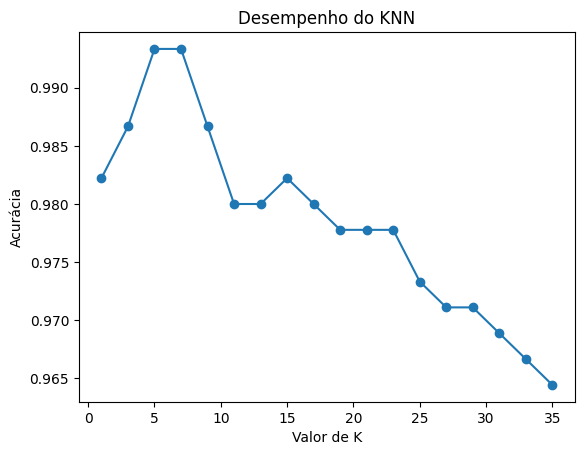

In [ ]:
plt.plot(k_values, acuracy_list, marker='o')
plt.title("Desempenho do KNN")
plt.xlabel("Valor de K")
plt.ylabel("Acurácia")
plt.show()

### Variância amostral dos pixels

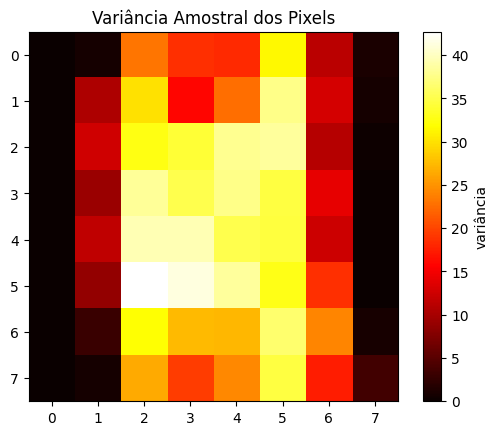

In [ ]:
var = np.var(X_train, axis=0)
img_var = var.reshape(8,8)
plt.imshow(img_var, cmap='hot')
plt.colorbar(label="variância")
plt.title("Variância Amostral dos Pixels")
plt.show()

#### Comentários sobre a Variância

É notável que na borda das imagens, principalmente na esquerda e direita, a variância é baixíssima e quanto mais ao centro nos direcionamos, maior é a variância dos pixels. Isto se deve principalmente por se tratar de imagens de desenhos, onde, na maioria das vezes, estes são feitos no centro de uma tela. 

### Imagens Classificadas Erroneamente

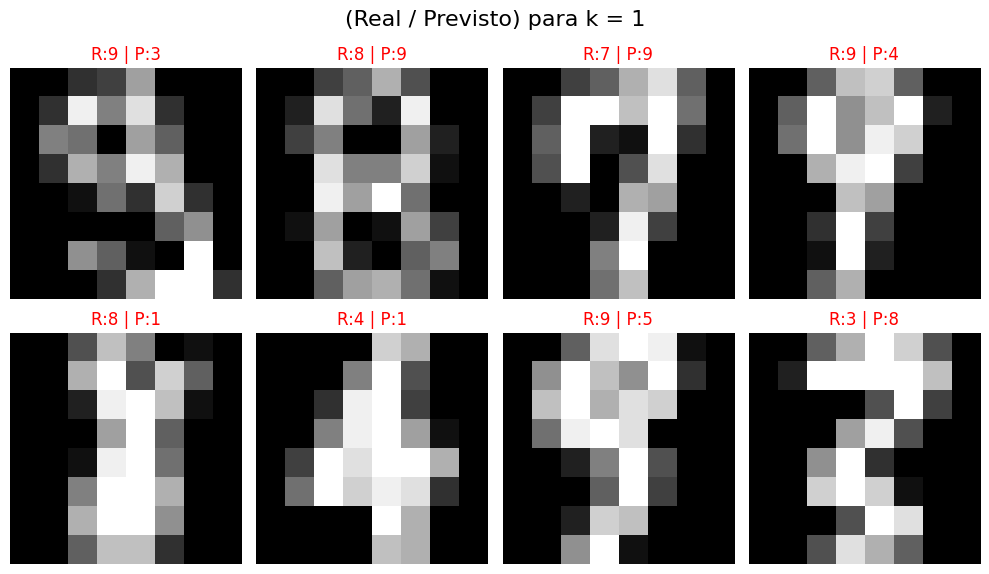

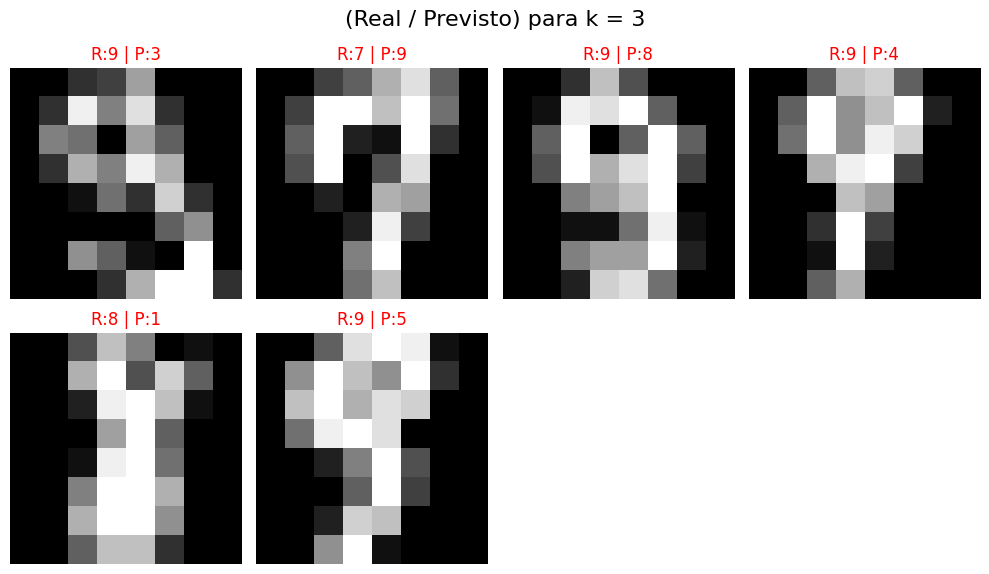

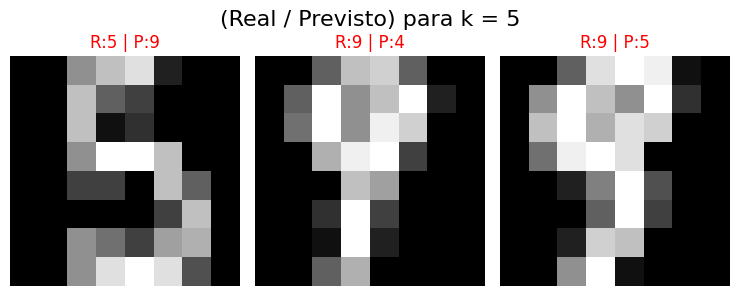

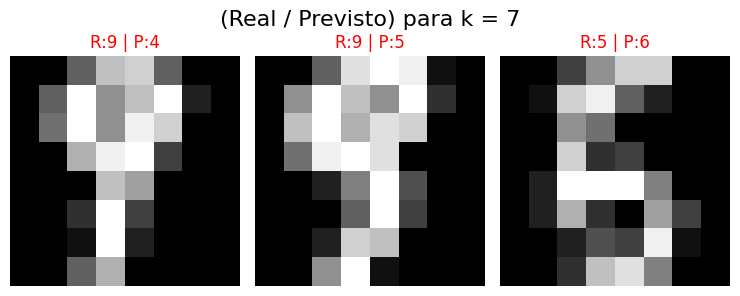

In [ ]:
for k in k_values[:4]:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    indices_precisoes_erradas = np.where(y_pred != y_test)[0]
    n_imagens = len(indices_precisoes_erradas)
    
    if n_imagens == 0: continue

    cols = int(np.ceil(np.sqrt(n_imagens * 2)))
    rows = int(np.ceil(n_imagens / cols))
    
    plt.figure(figsize=(cols * 2.5, rows * 3))
    plt.suptitle(f"(Real / Previsto) para k = {k}", fontsize=16)

    for indice_plot, indice_imagem in enumerate(indices_precisoes_erradas):
        plt.subplot(rows, cols, indice_plot + 1)
        plt.title(f"R:{y_test[indice_imagem]} | P:{y_pred[indice_imagem]}", color="red")
        plt.axis('off') 
        
        plot_img(index=indice_imagem, train=False, test=True, show=False)
        
    plt.tight_layout()
    plt.show()

**Exercício 02.** O código abaixo carrega o dataset "two moons", que consiste de amostras bidimensionais divididas em duas classes. Teste o $k$-NN com distância euclidiana para classificação do conjunto de teste. Use valores de $k$ diferentes (e.g., de 1 a 10). Plote a superfície de decisão para cada valor de $k$. Como $k$ influencia na suavidade dessas superfícies?

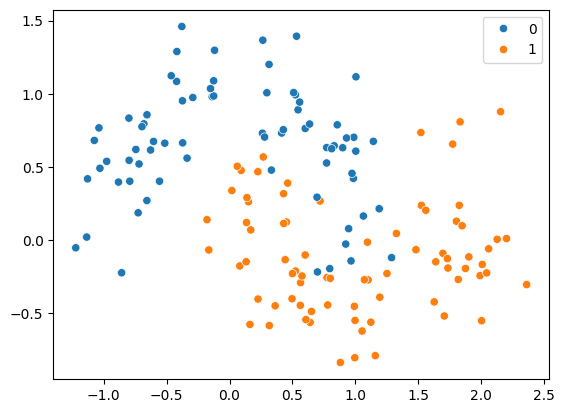

In [ ]:
# Import dataset and separate train/test subsets
moon = Dataset(*train_test_split(
    *make_moons(n_samples=200, shuffle=True, noise=0.25, random_state=SEED),
    random_state=SEED,
))

# Let's also plot the moon dataset, for you to take a look at it.
sns.scatterplot(
    x=moon.features_train[:, 0],
    y=moon.features_train[:, 1],
    hue=moon.labels_train,
)
plt.show()

k = 1 : Acurácia = 0.940000000


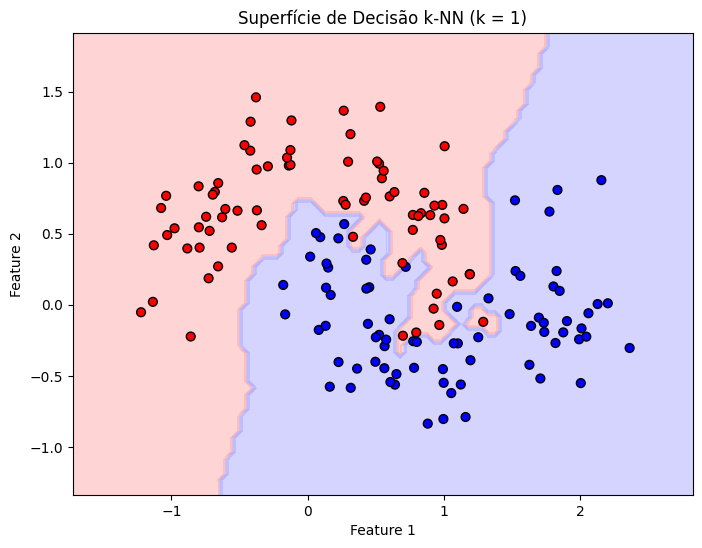

k = 101 : Acurácia = 0.800000000


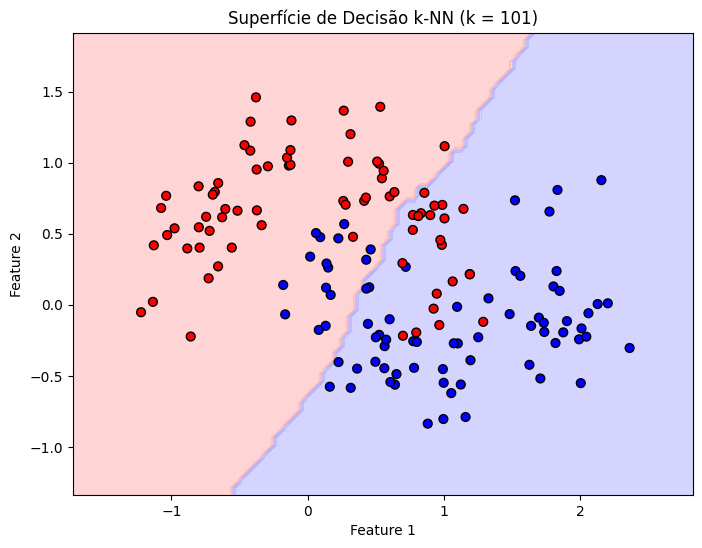

In [103]:
X_train = moon.features_train
X_test = moon.features_test
y_train = moon.labels_train
y_test = moon.labels_test

acuracy_list = []
k_values = [1, 101]
for k in k_values:
    knn = KNN(k = k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy(y_pred, y_test)
    acuracy_list.append(acc)
    print(f"k = {k} : Acurácia = {acc :.9f}")
    plot_decision_boundary(X_train, y_train, knn, k)

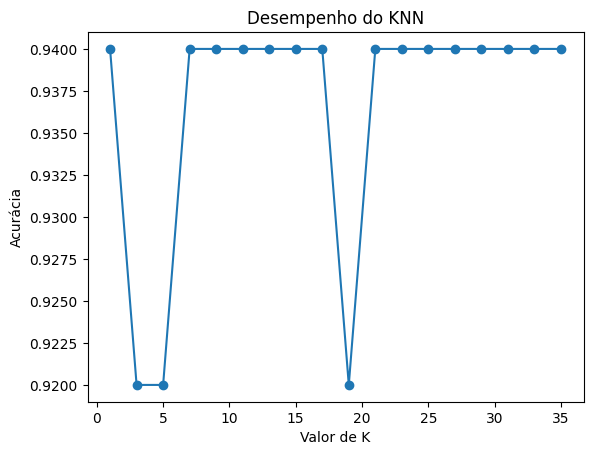

In [ ]:
plt.plot(k_values, acuracy_list, marker='o')
plt.title("Desempenho do KNN")
plt.xlabel("Valor de K")
plt.ylabel("Acurácia")
plt.show()

# Regressão linear

**Exercício 1.** Deixamos à sua disposição o dataset ["California Housing"](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing), dividio em treino, teste e validação.
O modelo que você utilizará para aproximar a relação funcional entre as features e as labels é o modelo linear, i.e., $\mathbf{y} = X\theta$.
Entretanto, você deve estimar seus parâmetros (minimizando o *mean squared error*) com **dois algoritmos diferentes**.
Uma implementação deve estimar $\theta$ por meio de **Stochastic Gradient Descent (SGD)** e, a outra, por meio de **Ordinary Least Squares (OLS)**, ou seja, utilizar a solução em fórmula fechada vista em aula.

Para o SGD, o ponto inicial deve ser escolhido aleatoriamente e o algoritmo deve parar quando a norma da diferença entre duas estimativas consecutivas de $\theta$ for menor do que um $\varepsilon > 0$ previamente especificado.
Para o experimento a seguir, fixe $\varepsilon$ em um valor pequeno (por exemplo, alguma potência de $1/10$) para a qual o algoritmo convirja no máximo em alguns minutos para uma solução com perda pequena.

Para diferentes tamanhos de minibatch (por exemplo $\{2^{j}: 1 \leq j \leq 7\}$), plote um gráfico representando o valor da perda $ L(\hat{\theta}) = \frac{1}{n} \lVert X \hat{\theta} - \mathbf{y} \rVert^{2}$ no conjunto de validação em função do número de epochs. Mostre também o valor ótimo obtido com OLS. Comente os resultados e o efeito tamanho do mini-batch, e.g., no tempo de treinamento. Reporte valores nos conjuntos de treino, validação e teste.

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


SEED = 42
np.random.seed(SEED)


features, labels = fetch_california_housing(return_X_y=True)
features_train, features_test, labels_train, labels_test = train_test_split(
    features, labels, test_size==0.25
)
features_train, features_validation, labels_train, labels_validation = train_test_split(
    features_train, labels_train, test_size=0.25
)

NameError: name 'test_size' is not defined

**Exercício 2.** Agora, você deve implementar uma **Rede RBF** com função de base Gaussiana (veja as notas de aula).
Para os centróides, utilize o output de um modelo de clusterização por K médias, por meio da função que disponibilizamos, como a seguir:

In [ ]:
def k_means_factory(n_clusters: int) -> KMeans:
    return KMeans(n_clusters=n_clusters, n_init="auto")

k_means_model = k_means_factory(n_clusters=2)
dumb_data = np.array(
    [[1, 2],
     [1, 4],
     [1, 0],
     [10, 2],
     [10, 4],
     [10, 0]]
)
k_means_model.fit(dumb_data)
cluster_centers = k_means_model.cluster_centers_
print(cluster_centers) # Shape (n_clusters, n_features)

Para determinar o melhor valor de $k$ para o algoritmo de clusterização, treine o modelo (usando a fórmula de OLS) com diferentes valores e escolha o que possuir o menor erro de validação. Faça um gráfico mostrando o valor do erro de validação para diferentes valores de $k$. Mostre também a performance do modelo escolhido no conjunto de teste. Compare com o modelo linear simples da questão anterior. Discuta os resultados.

Para definir o valor do hiper-parâmetro $\gamma$, use a seguinte heurística --- que pode ser achado no livro "Neural Networks", por Simon Haykin:

$$
\gamma = \frac{1}{d_\text{max}^2},
$$

onde $d_\text{max}$ é a maior distância entre um par de centróides. Note que o valor costuma mudar para $k$'s diferentes.


## Regressão logística

O pedaço de código abaixo carrega o banco de dados 'breast cancer' e adiciona uma coluna de bias. Além disse, ele o particiona em treino e teste.

1. Implemente a estimativa de máximo a posteriori para um modelo de regressão logística com priori $\mathcal{N}(0, c I)$ com $c=100$ usando esse banco de dados;
2. Implemente a aproximação de Laplace para o mesmo modelo;
3. Implemente uma aproximação variacional usando uma Gaussiana diagonal e o truque da reparametrização;
4. Calcule a accuracy no teste para todas as opções acima --- no caso das 2 últimas, a prob predita é $\int_\theta p(y|x, \theta) q(\theta)$;
5. Para cada uma das 3 técnicas, plote um gráfico com a distribuição das entropias para as predições corretas e erradas (separadamente), use a função kdeplot da biblioteca seaborn.
6. Comente os resultados, incluindo uma comparação dos gráficos das entropias.

Explique sua implementação também! 

Para (potencialmente) facilitar sua vida: use PyTorch, Adam como otimizador (é uma variação SGD) com lr=0.001, use o banco de treino inteiro ao invés de minibatchces, use binary_cross_entropy_with_logits para implementar a -log verossimilhança, use torch.autograd.functional para calcular a Hessiana. Você pode usar as bibliotecas importadas na primeira célula a vontade. Verifique a documentação de binary_cross_entropy_with_logits para garantir que a sua priori está implementada corretamente, preservando as proporções devidas. Use 10000 amostras das aproximações para calcular suas predições.

In [ ]:
data =  load_breast_cancer()
N = len(data.data)
Ntrain = int(np.ceil(N*0.6))
perm = np.random.permutation(len(data.data))
X = torch.tensor(data.data).float()
X = torch.cat((X, torch.ones((X.shape[0], 1))), axis=1) 
y = torch.tensor(data.target).float()

Xtrain, ytrain = X[perm[:Ntrain]], y[perm[:Ntrain]]
Xtest, ytest = X[perm[Ntrain:]], y[perm[Ntrain:]]